# PARTICIPANT 7

This script processes environmental monitoring data collected from various sources including Eltek, bathroom sensors, bedroom CO2 sensors, weather data, and noise sensors. The script cleans, merges, and calibrates this data to create a consolidated dataset. Additionally, it identifies and handles issues in the data (e.g., sensor errors) and prepares the data for further analysis.

**Key features:**
- Ingest and preprocess environmental data from multiple sources.
- Calibrate and baseline CO2 and noise data.
- Handle missing, infinite, and erroneous data points.
- Generate dictionaries categorizing data by room and type for analysis.

**Notes about campaign:**
1. Small amounts of data missing from bedroom 2 at the beginning of the campaign
2. kitchen_window_event open for 6 weeks in October - this looks wrong...

## Import Packages and Functions

In [1]:
# -*- coding: utf-8 -*-
#!/usr/bin/python

import os

# run shared function notebooks to load all functions
%run functions.ipynb
%run plotting_functions.ipynb

Packages loaded.

All functions have been defined.


## Load Eltek Data

Load environmental data from the Eltek AQ110a sensor system.

In [2]:
p7_eltek = ingest_aq110a(path = '../data/p7_london_terraced/data_unprocessed/K01830-12197.csv'
                      , import_variables = ['','temperature', 'humidity', 'co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc'
                                            , 'temperature', 'humidity', 'co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc'
                                            ,'temperature', 'humidity', 'co2'
                                            ,'temperature', 'humidity', 'co2'
                                            ]
                      , column_names = ['living_temperature', 'living_humidity', 'living_co2', 'living_1um', 'living_25um', 'living_100um', 'living_airflow', 'living_no2', 'living_co1', 'living_voc',
                                        'external_temperature', 'external_humidity', 'external_co2', 'external_1um', 'external_25um', 'external_100um', 'external_airflow', 'external_no2', 'external_co1', 'external_voc',
                                        'bedroom1_temperature', 'bedroom1_humidity', 'bedroom1_co2',
                                        'bedroom2_temperature', 'bedroom2_humidity', 'bedroom2_co2'
                                        ]
                      , convert_no2 = True
                      , convert_co = True
                      , input_interpolate = True
                      , input_iterpolate_limit = 6
                      )

p7_eltek = p7_eltek.reset_index()
# delete external temp and rh
del p7_eltek['external_temperature']
del p7_eltek['external_humidity']

# baseline co1 and no2
aq110a_no2_co1_baseline (input_dataframe = p7_eltek
                             , input_percentile = 5)


---------------------------------------------
Ingesting AQ110a data from ../data/p7_london_terraced/data_unprocessed/K01830-12197.csv


/var/folders/6m/c2f6bq0j2fbclrsw82pn99380000gn/T/ipykernel_94908/1228987109.py:59: DtypeWarning: Columns (1,2,3,9,10,21,22,23,24,25,26) have mixed types. Specify dtype option on import or set low_memory=False.
  eltek = pd.read_csv(path, skiprows = 3) # ingest



Correction

-----------------------
34646_temperature
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
34646_humidity
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
34646_co2
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
34646_1um
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
34646_25um
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
34646_100um
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
34646_airflow
baseline_correction

False


## Load Bathroom Data

Load bathroom temperature, humidity, and light data from multiple U12-012 sensors.

**Deployments (first to last):**
- U12-012 EI130264 (10459129): FF Bathroom
- U12-012 EI130446 (1068744): FF Bathroom
- U12-012 EI130469 (1088070): FF Bathroom

In [3]:
#### bathroom - file 1
p7_bathroom_ieq_1 = ingest_u12_012('../data/p7_london_terraced/data_unprocessed/211209_EI130469.csv'
                      , 0
                      , ['date', 'time', 'bathroom_temperature', 'bathroom_humidity', 'bathroom_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130469'
                      )

#### bathroom - file 2
#220302_ei130297
p7_bathroom_ieq_2 = ingest_u12_012('../data/p7_london_terraced/data_unprocessed/220302_EI130446.csv'
                      , 0
                      , ['date', 'time', 'bathroom_temperature', 'bathroom_humidity', 'bathroom_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130446'
                      )

#### bathroom - file 3
p7_bathroom_ieq_3 = ingest_u12_012('../data/p7_london_terraced/data_unprocessed/220429_EI130264.csv'
                      , 0
                      , ['date', 'time', 'bathroom_temperature', 'bathroom_humidity', 'bathroom_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130264'
                      )


---------------------------------------------
Ingesting U12-012 data from ../data/p7_london_terraced/data_unprocessed/211209_EI130469.csv
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
Missing data = 
 bathroom_temperature    0
bathroom_humidity       0
bathroom_light          0
dtype: int64
U12-012 data ingested
---------------------------------------------


---------------------------------------------
Ingesting U12-012 data from ../data/p7_london_terraced/data_unprocessed/220302_EI130446.csv
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
Missing data = 
 bathroom_temperature    0
bathroom_humidity       0
bathroom

## Join Bathroom Data

Concatenate bathroom data from different time periods:
- File 1: beginning to 2021-12-08 11:10
- File 2: 2021-12-08 11:15 to 2022-02-08 09:40
- File 3: 2022-02-08 09:45 to end

In [4]:
#### join all bathroom 1
p7_bathroom_ieq_1 = p7_bathroom_ieq_1.loc[:'2021-12-08 11:10:00']
p7_bathroom_ieq_2 = p7_bathroom_ieq_2.loc['2021-12-08 11:15:00':'2022-02-28 09:40:00']
p7_bathroom_ieq_3 = p7_bathroom_ieq_3.loc['2022-02-28 09:45:00':]
p7_dfs = [p7_bathroom_ieq_1, p7_bathroom_ieq_2, p7_bathroom_ieq_3]
p7_bathroom = pd.concat(p7_dfs)
p7_bathroom = p7_bathroom.resample('5min').ffill() # resample and backfill for 5 mins
del p7_bathroom_ieq_1, p7_bathroom_ieq_2, p7_bathroom_ieq_3
del p7_dfs
p7_bathroom = p7_bathroom.copy()

## Load Ground Floor WC Data

Load gfwc temperature, humidity, and light data from multiple U12-012 sensors.

**Deployments (first to last):**
- U12-012 EI130509 (10459122): GF WC
- U12-012 EI130297 (10459122): GF WC
- U12-012 EI130565 (1088126): GF WC

In [5]:
#### gfwc - file 1
p7_gfwc_ieq_1 = ingest_u12_012('../data/p7_london_terraced/data_unprocessed/211209_EI130509.csv'
                      , 0
                      , ['date', 'time', 'gfwc_temperature', 'gfwc_humidity', 'gfwc_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130509'
                      )

#### gfwc - file 2
# 220302_ei130530
p7_gfwc_ieq_2 = ingest_u12_012('../data/p7_london_terraced/data_unprocessed/220302_EI130297.csv'
                      , 0
                      , ['date', 'time', 'gfwc_temperature', 'gfwc_humidity', 'gfwc_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130297'
                      )

#### gfwc - file 3
p7_gfwc_ieq_3 = ingest_u12_012('../data/p7_london_terraced/data_unprocessed/220429_EI130565.csv'
                      , 0
                      , ['date', 'time', 'gfwc_temperature', 'gfwc_humidity', 'gfwc_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130565'
                      )


---------------------------------------------
Ingesting U12-012 data from ../data/p7_london_terraced/data_unprocessed/211209_EI130509.csv
baseline_correction

True
<class 'float'>
0.0
slope

True
<class 'float'>
1.0
intercept

True
<class 'float'>
0.0
baseline_correction

True
<class 'float'>
0.0
slope

True
<class 'float'>
1.0
intercept

True
<class 'float'>
0.0
Missing data = 
 gfwc_temperature    0
gfwc_humidity       0
gfwc_light          0
dtype: int64
U12-012 data ingested
---------------------------------------------


---------------------------------------------
Ingesting U12-012 data from ../data/p7_london_terraced/data_unprocessed/220302_EI130297.csv
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
Missing data = 
 gfwc_temperature    0
gfwc_humidity       0
gfwc_light          0
dtype: int64

## Join Ground Floor WC Data

Concatenate gfwc data from different time periods.

In [6]:
#### join all p7_gfwc 1
p7_gfwc_ieq_1 = p7_gfwc_ieq_1.loc[:'2021-12-08 10:25:00']
p7_gfwc_ieq_2 = p7_gfwc_ieq_2.loc['2021-12-08 10:30:00':'2022-02-28 15:15:00']
p7_gfwc_ieq_3 = p7_gfwc_ieq_3.loc['2022-02-28 15:20:00':]
p7_dfs = [p7_gfwc_ieq_1, p7_gfwc_ieq_2, p7_gfwc_ieq_3]
p7_gfwc = pd.concat(p7_dfs)
p7_gfwc = p7_gfwc.resample('5min').ffill() # resample and backfill for 5 mins
del p7_gfwc_ieq_1, p7_gfwc_ieq_2, p7_gfwc_ieq_3
del p7_dfs
p7_gfwc = p7_gfwc.copy()

## Load Office Data

Load office temperature, humidity, and light data from multiple U12-012 sensors.

**Deployments (first to last):**
- U12-012 EI130565 (1088126): Office/study
- U12-012 EI130530 (10065116): Office/study
- U12-012 EI130509: Office/study

In [7]:
#### office - file 1
p7_office_ieq_1 = ingest_u12_012('../data/p7_london_terraced/data_unprocessed/211209_EI130565.csv'
                      , 0
                      , ['date', 'time', 'office_temperature', 'office_humidity', 'office_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130565'
                      )

#### office - file 2
p7_office_ieq_2 = ingest_u12_012('../data/p7_london_terraced/data_unprocessed/220302_EI130530.csv'
                      , 0
                      , ['date', 'time', 'office_temperature', 'office_humidity', 'office_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130530'
                      )

#### office - file 3
p7_office_ieq_3 = ingest_u12_012('../data/p7_london_terraced/data_unprocessed/220429_EI130509.csv'
                      , 0
                      , ['date', 'time', 'office_temperature', 'office_humidity', 'office_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130509'
                      )


---------------------------------------------
Ingesting U12-012 data from ../data/p7_london_terraced/data_unprocessed/211209_EI130565.csv
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
Missing data = 
 office_temperature    0
office_humidity       0
office_light          0
dtype: int64
U12-012 data ingested
---------------------------------------------


---------------------------------------------
Ingesting U12-012 data from ../data/p7_london_terraced/data_unprocessed/220302_EI130530.csv
baseline_correction

True
<class 'float'>
0.0
slope

True
<class 'float'>
1.0
intercept

True
<class 'float'>
0.0
baseline_correction

True
<class 'float'>
0.0
slope

True
<class 'float'>
1.0
intercept

True
<class 'float'>
0.0
Missing data = 
 office_temperature    0
office_humidity       0
office_light          0


## Join Office Data

Concatenate office data from different time periods.

In [8]:
#### join all p7_office 1
p7_office_ieq_1 = p7_office_ieq_1.loc[:'2021-12-08 11:10:00']
p7_office_ieq_2 = p7_office_ieq_2.loc['2021-12-08 11:15:00':'2022-02-28 17:30:00']
p7_office_ieq_3 = p7_office_ieq_3.loc['2022-02-28 17:35:00':]
p7_dfs = [p7_office_ieq_1, p7_office_ieq_2, p7_office_ieq_3]
p7_office = pd.concat(p7_dfs)
p7_office = p7_office.resample('5min').ffill() # resample and backfill for 5 mins
del p7_office_ieq_1, p7_office_ieq_2, p7_office_ieq_3
del p7_dfs
p7_office = p7_office.copy()

## Load Bedroom 3 Data

Load bedroom 3 temperature, humidity, and CO2 data from multiple MX1102 sensors.

**Deployments (first to last):**
- MX1102A EI130715 (20430189): Bedroom 3
- MX1102A EI130720 (20430195): Bedroom 3
- MX1102A EI130716 (20430190): Bedroom 3

In [9]:
p7_bedroom3_ieq_1 = ingest_mx1102("../data/p7_london_terraced/data_unprocessed/211209_EI130715.csv"
                     , 1
                     , ['date', 'time', 'bedroom3_temperature', 'bedroom3_humidity', 'bedroom3_co2']
                     , '5min'
                     , True
                     ,  instrument_ref = 'EI130715'
                     , index_as_date = True
                     )

p7_bedroom3_ieq_2 = ingest_mx1102("../data/p7_london_terraced/data_unprocessed/220302_EI130720.csv"
                     , 1
                     , ['date', 'time', 'bedroom3_temperature', 'bedroom3_humidity', 'bedroom3_co2']
                     , '5min'
                     , True
                     ,  instrument_ref = 'EI130720'
                     , index_as_date = True
                     )

p7_bedroom3_ieq_3 = ingest_mx1102("../data/p7_london_terraced/data_unprocessed/220429_EI130716.csv"
                     , 1
                     , ['date', 'time', 'bedroom3_temperature', 'bedroom3_humidity', 'bedroom3_co2']
                     , '5min'
                     , True
                     ,  instrument_ref = 'EI130716'
                     , index_as_date = True
                     )


---------------------------------------------
Ingesting MX1102 data from ../data/p7_london_terraced/data_unprocessed/211209_EI130715.csv
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
Missing data = 
 bedroom3_temperature    0
bedroom3_humidity       0
bedroom3_co2            0
dtype: int64
MX1102 data ingested
---------------------------------------------


---------------------------------------------
Ingesting MX1102 data from ../data/p7_london_terraced/data_unprocessed/220302_EI130720.csv
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0


## Join Bedroom 3 Data

Concatenate bedroom 3 data from different time periods.

In [10]:
#### join all bedroom 3
# p7_bedroom3_ieq_1 = p7_bedroom3_ieq_1.loc[:'2021-03-01 12:00:00']
p7_bedroom3_ieq_2 = p7_bedroom3_ieq_2.loc['2021-12-07 15:55:00':]
p7_bedroom3_ieq_3 = p7_bedroom3_ieq_3.loc['2022-02-27 20:55:00':]
p7_dfs = [p7_bedroom3_ieq_1, p7_bedroom3_ieq_2, p7_bedroom3_ieq_3]
p7_bedroom3 = pd.concat(p7_dfs)
p7_bedroom3 = p7_bedroom3.resample('5min').ffill() # resample and backfill for 5 mins
del p7_bedroom3_ieq_1, p7_bedroom3_ieq_2, p7_bedroom3_ieq_3
del p7_dfs
p7_bedroom3 = p7_bedroom3.copy()

## Merge All Indoor Data

In [11]:


p7_dfs = [p7_eltek, p7_bedroom3, p7_bathroom, p7_gfwc, p7_office] # create a list with all p7_dfs to be merged
p7 = reduce(lambda left,right: pd.merge(left,right,on='date', how='outer'), p7_dfs) # merge
p7 = p7.sort_index() # sort by index
#### clean-up
del p7_dfs, p7_eltek, p7_bedroom3, p7_bathroom, p7_gfwc, p7_office
p7.isna().sum() #should equal 0
p7.duplicated()
p7 = p7.sort_values(by=['date'])
p7 = p7.reset_index(drop=True)
# set date as index
p7 = p7.set_index(p7['date'])
# delete date
del p7['date']

## CO2 Column List

In [12]:
p7_co2_col_list = co2_col_list(p7)

## CO2 Calibration Based on Unoccupied Periods

Calibrate indoor CO2 sensors using outdoor reference values during unoccupied periods.

**Note:** Fixing an issue with bedroom 2 between 2021-09-16 16:30 and 2021-09-16 17:20 by copying data from bedroom 1 for this period.

In [13]:


# fixing an issue with bedroom 2 between '2021-09-16 16:30:00', '2021-09-16 17:20:00' - copying data from bedroom 1 for this period
p7.loc['2021-09-16 16:30:00':'2021-09-16 17:20:00', 'bedroom2_co2'] = p7.loc['2021-09-16 16:30:00':'2021-09-16 17:20:00', 'bedroom1_co2']


co2_correction_unoccupied(input_dataframe = p7
                          , input_start_and_end_as_df = True
                          , input_start_date = ''
                          , input_end_date = ''
                          , input_list_unoccupied_periods = ['2021-09-16 16:30:00', '2021-09-16 17:20:00',
                                                             '2021-12-25 00:00:00', '2022-01-03 00:00:00',
                                                             '2022-02-21 16:00:00', '2022-02-21 16:30:00',
                                                             '2022-04-15 00:00:00', '2022-04-25 00:00:00',
                                                             ]
                          , input_outdoor_co2_col = 'external_co2'
                          , input_co2_cols_to_correct = ['living_co2',
                                                        'bedroom1_co2',
                                                        'bedroom2_co2',
                                                        'bedroom3_co2']
                          , input_percentile_indoor = 10
                          , input_percentile_outdoor = 50
                          )


====    Start of CO2 correction    ====


Using beginning and end dates from input df
Start date =  2021-09-10 12:00:00
End date =  2022-05-06 17:35:00

-------------------------------------------------------------
----     Correcting:  living_co2     ----
-------------------------------------------------------------

Loop 1
Start of unoccupied period 1 = 2021-09-16 16:30:00
End of unoccupied period 1 = 2021-09-16 17:20:00
Mid point = 2021-09-16 16:55:00
Indoor CO2 10 th percentile is  443.0
Outdoor CO2 50 th percentile is  447.0
Difference in CO2 10 th percentiles is  -4.0

Loop 2
Start of unoccupied period 2 = 2021-12-25 00:00:00
End of unoccupied period 2 = 2022-01-03 00:00:00
Mid point = 2021-12-29 12:00:00
Length between previous mid and this mid 29894
Indoor CO2 10 th percentile is  457.0
Outdoor CO2 50 th percentile is  466.0
Difference in CO2 10 th percentiles is  -9.0
Offset difference =  -5.0
Slope =  -0.00016725764367431592

Loop 3
Start of unoccupied period 3 = 2022-02-21 

## Filter DataFrame Based on Campaign Dates (Initial)

In [14]:


monitoring_start_date = '2021-09-15 00:00:00'
monitoring_end_date = '2022-04-29 00:00:00'
p7 = p7.loc[monitoring_start_date : monitoring_end_date]

## Import Event Data

Load window and door event data from UX90-001M sensors.

**Sensors:**
- UX90-001M EI130797 (20400100): bedroom3_window_event
- UX90-001M EI130815 (20400118): bedroom1_window1_event
- UX90-001M EI130814 (20400117): bedroom1_window2_event
- UX90-001M EI130816 (20400119): bedroom2_window_event
- UX90-001M EI130803 (20400106): kitchen_window_event
- UX90-001M EI130839 (20425362): office_window_event
- UX90-001M EI130819 (20400122): bathroom_window_event
- UX90-001M EI130822 (20400125): main_door_event
- UX90-001M EI130824 (20425347): living_sliding_door_event

In [15]:


"""
UX90-001M	EI130797	20400100    bedroom3_window_event
UX90-001M	EI130815	20400118    bedroom1_window1_event
UX90-001M	EI130814	20400117    bedroom1_window2_event
UX90-001M	EI130816	20400119    bedroom2_window_event
UX90-001M	EI130803	20400106    kitchen_window_event
UX90-001M	EI130839	20425362    office_window_event
UX90-001M	EI130819	20400122    bathroom_window_event
UX90-001M	EI130822	20400125    main_door_event
UX90-001M	EI130824	20425347    living_sliding_door_event
"""

p7_event_dict = ingest_ux90_001m_group_new(input_file_list =
                           ['../data/p7_london_terraced/data_unprocessed/220429_EI130797.csv',
                           '../data/p7_london_terraced/data_unprocessed/220429_EI130815.csv',
                           '../data/p7_london_terraced/data_unprocessed/220429_EI130814.csv',
                           '../data/p7_london_terraced/data_unprocessed/220429_EI130816.csv',
                           '../data/p7_london_terraced/data_unprocessed/220429_EI130803.csv',
                           '../data/p7_london_terraced/data_unprocessed/220429_EI130839.csv',
                           '../data/p7_london_terraced/data_unprocessed/220429_EI130819.csv',
                           '../data/p7_london_terraced/data_unprocessed/220429_EI130822.csv',
                           '../data/p7_london_terraced/data_unprocessed/220429_EI130824.csv'
                           ]
                       , input_output_name_list =
                           [
                           'bedroom3_window_event',
                           'bedroom1_window1_event',
                           'bedroom1_window2_event',
                           'bedroom2_window_event',
                           'kitchen_window_event',
                           'office_window_event',
                           'bathroom_window_event',
                           'main_door_event',
                           'living_sliding_door_event'
                            ]
                       , input_skiprows = 0
                       , input_main_dataframe = p7
                       )


event_durations(input_event_dict = p7_event_dict)
p7_event_dict['main_door_event'] = p7_event_dict['main_door_event'].set_index(p7_event_dict['main_door_event']['date'])
#### list of all events
p7_event_list = event_list_function(input_event_dict = p7_event_dict)


---------------------------------------------
Ingesting ux90_001m data from ../data/p7_london_terraced/data_unprocessed/220429_EI130797.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p7_london_terraced/data_unprocessed/220429_EI130815.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p7_london_terraced/data_unprocessed/220429_EI130814.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p7_london_terraced/data_unprocessed/220429_EI130816.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p7_london_terraced/data_unprocessed/220429_EI130803.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p7_london_terraced/data_unprocessed/220429_EI130839.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p7_london_terraced/data_unprocessed/220429_EI130819.csv

------------

## Import Occupancy Data

Load occupancy sensor data from UX90-006M sensors.

**Sensors:**
- UX90-006M 20608906: Entrance hall
- UX90-006M 20425583: Living

In [16]:
"""
UX90-006M	NA	20608906	Entrance hall
UX90-006M	NA	20425583	Living
"""

p7_occupancy_dict = ingest_ux90_006_group(input_file_list = ['../data/p7_london_terraced/data_unprocessed/220429_20608906.csv',
                                                          '../data/p7_london_terraced/data_unprocessed/220429_20425583.csv',]
                                                          , output_name_list = ['main_door_occupancy',
                                                                                'living_occupancy']
                                                          , skiprows = 0
                                                          )


---------------------------------------------
Ingesting ux90_006 data from ../data/p7_london_terraced/data_unprocessed/220429_20608906.csv
Non-unique observations =  0
                    date  main_door_occupancy
0    2021-09-10 12:00:00                  0.0
1    2021-09-11 11:32:16                  1.0
2    2021-09-11 11:47:23                  0.0
3    2021-09-13 11:30:49                  1.0
4    2021-09-13 13:04:03                  0.0
...                  ...                  ...
6832 2022-04-29 10:53:44                  0.0
6833 2022-04-29 10:54:04                  1.0
6834 2022-04-29 12:10:30                  0.0
6835 2022-04-29 14:30:55                  1.0
6836 2022-04-29 14:49:58                  1.0

[6837 rows x 2 columns]
ux90_006 data ingested
---------------------------------------------


---------------------------------------------
Ingesting ux90_006 data from ../data/p7_london_terraced/data_unprocessed/220429_20425583.csv
Non-unique observations =  0
               

## Import Weather Data

Load external weather data from CEDA.

In [17]:
p7_weather = ingest_ceda_weather_data(input_path = '../data/p7_london_terraced/data_unprocessed/weather.csv'
                         , skiprows = 0
                         , cols_from_ceda = ['ob_time', ' wind_direction', ' wind_speed', ' air_temperature', ' dewpoint', ' wetb_temp', ' rltv_hum']
                         , new_col_names = ['date', 'external_wind_direction', 'external_wind_speed', 'external_temperature', 'external_dewpoint', 'external_wetb_temp', 'external_humidity']
                         )


---------------------------------------------
Ingesting weather data from ../data/p7_london_terraced/data_unprocessed/weather.csv
nans before interpolating =  external_wind_direction    19
external_wind_speed        19
external_temperature        2
external_dewpoint           2
external_wetb_temp          2
external_humidity           2
dtype: int64
nans before interpolating =  external_wind_direction    0
external_wind_speed        0
external_temperature       0
external_dewpoint          0
external_wetb_temp         0
external_humidity          0
dtype: int64
Weather data ingested


## Import Raspberry Pi Noise Data

Load and process noise measurement data from Raspberry Pi microphones (PHEUCLio012).

In [18]:
p7_noise_dict, p7_noise_inside, p7_noise_outside =  rpi_noise_ingest(input_start_directory = '../data/p7_london_terraced/data_unprocessed/noise/')

## Merge Weather and Noise Data into Main DataFrame

In [19]:
p7_dfs = [p7, p7_noise_inside, p7_noise_outside, p7_weather]
p7 = reduce(lambda left,right: pd.merge(left,right,on='date', how='outer'), p7_dfs)
p7 = p7.sort_values(by=['date'])
# rename noise
"""
PHEUCLio012_in
PHEUCLio012_out
"""
p7 = p7.rename(columns={'PHEUCLio012_in': 'inside_dba', 'PHEUCLio012_out': 'external_noise'})
del p7_dfs, p7_noise_inside, p7_noise_outside, p7_weather

## Filter DataFrame Based on Campaign Dates (Post-Merge)

In [20]:

p7 = p7.loc[monitoring_start_date : monitoring_end_date]

## Create Room and Variable Dictionary

Generate a dictionary organizing all measured variables by room.

In [21]:
p7_variable_list = ['temperature',
                 'humidity',
                 'co2',
                 '1um',
                 '25um',
                 '100um',
                 'airflow',
                 'no2',
                 'co1',
                 'voc',
                 'light'
                 ]

p7_rooms_and_variables = rooms_variables_dict(input_dataframe = p7
                      ,variables = p7_variable_list)

bathroom









['temperature', 'humidity', 'light']
external









['co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc', 'noise', 'wind_direction', 'wind_speed', 'temperature', 'dewpoint', 'wetb_temp', 'humidity']
living









['temperature', 'humidity', 'co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc']
gfwc









['temperature', 'humidity', 'light']
bedroom3









['temperature', 'humidity', 'co2']
bedroom1









['temperature', 'humidity', 'co2']
bedroom2









['temperature', 'humidity', 'co2']
office









['temperature', 'humidity', 'light']


## Create Room and Event Dictionary

Define which events are associated with each room.

In [22]:
p7_rooms_list = ['living', 'bathroom', 'gfwc', 'bedroom1', 'bedroom2', 'bedroom3', 'office']
p7_living_events = ['living_sliding_door_event', 'kitchen_window_event']
p7_bathroom_events = ['bathroom_window_event']
p7_gfwc_events = []
p7_bedroom1_events = ['bedroom1_window1_event', 'bedroom1_window2_event']
p7_bedroom2_events = ['bedroom2_window_event']
p7_bedroom3_events = ['bedroom3_window_event']
p7_office_events = ['office_window_event']

p7_rooms_and_events = {}
p7_rooms_and_events['living'] = p7_living_events
p7_rooms_and_events['bathroom'] = p7_bathroom_events
p7_rooms_and_events['gfwc'] = p7_gfwc_events
p7_rooms_and_events['bedroom1'] = p7_bedroom1_events
p7_rooms_and_events['bedroom2'] = p7_bedroom2_events
p7_rooms_and_events['bedroom3'] = p7_bedroom3_events
p7_rooms_and_events['office'] = p7_office_events

del p7_living_events, p7_bathroom_events, p7_gfwc_events, p7_bedroom1_events, p7_bedroom2_events, p7_bedroom3_events, p7_office_events

## Final Data Filtering and Interpolation

Apply final date filters, filter event dictionary, and interpolate missing values.

In [23]:


p7 = p7.loc[monitoring_start_date : monitoring_end_date]
# filter event dict:
for loop_df in p7_event_dict:
    p7_event_dict[loop_df] = p7_event_dict[loop_df][(p7_event_dict[loop_df]['date'] > monitoring_start_date) & (p7_event_dict[loop_df]['date'] < monitoring_end_date)]

# interpolate all variables
for loop_room in p7_rooms_and_variables:
    print('')
    print(loop_room)
    for loop_variable in p7_rooms_and_variables[loop_room]:
        print(loop_room + '_' + loop_variable)
        print('--- Before ---')
        print('NaNs = ', p7[loop_room + '_' + loop_variable].isna().sum()) # count nans
        print('inf = ', len(p7[loop_room + '_' + loop_variable]) - np.isfinite(p7[loop_room + '_' + loop_variable]).sum()) # count all infinite values
        print('--- After ---')
        p7[loop_room + '_' + loop_variable] = p7[loop_room + '_' + loop_variable].interpolate(method='linear', limit = 4, limit_direction='forward')
        print('NaNs = ', p7[loop_room + '_' + loop_variable].isna().sum()) # count nans
        print('inf = ', len(p7[loop_room + '_' + loop_variable]) - np.isfinite(p7[loop_room + '_' + loop_variable]).sum()) # count all infinite


bathroom
bathroom_temperature
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =  0
bathroom_humidity
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =  0
bathroom_light
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =  0

external
external_co2
--- Before ---
NaNs =  241
inf =  241
--- After ---
NaNs =  231
inf =  231
external_1um
--- Before ---
NaNs =  5507
inf =  5507
--- After ---
NaNs =  5143
inf =  5143
external_25um
--- Before ---
NaNs =  5507
inf =  5507
--- After ---
NaNs =  5143
inf =  5143
external_100um
--- Before ---
NaNs =  5568
inf =  5568
--- After ---
NaNs =  5187
inf =  5187
external_airflow
--- Before ---
NaNs =  241
inf =  241
--- After ---
NaNs =  231
inf =  231
external_no2
--- Before ---
NaNs =  241
inf =  241
--- After ---
NaNs =  231
inf =  231
external_co1
--- Before ---
NaNs =  241
inf =  241
--- After ---
NaNs =  231
inf =  231
external_voc
--- Before ---
NaNs =  244
inf =  244
--- After ---
NaNs =  231
inf =  231
ex

## Plot Results

Generate plots of all grouped variables.

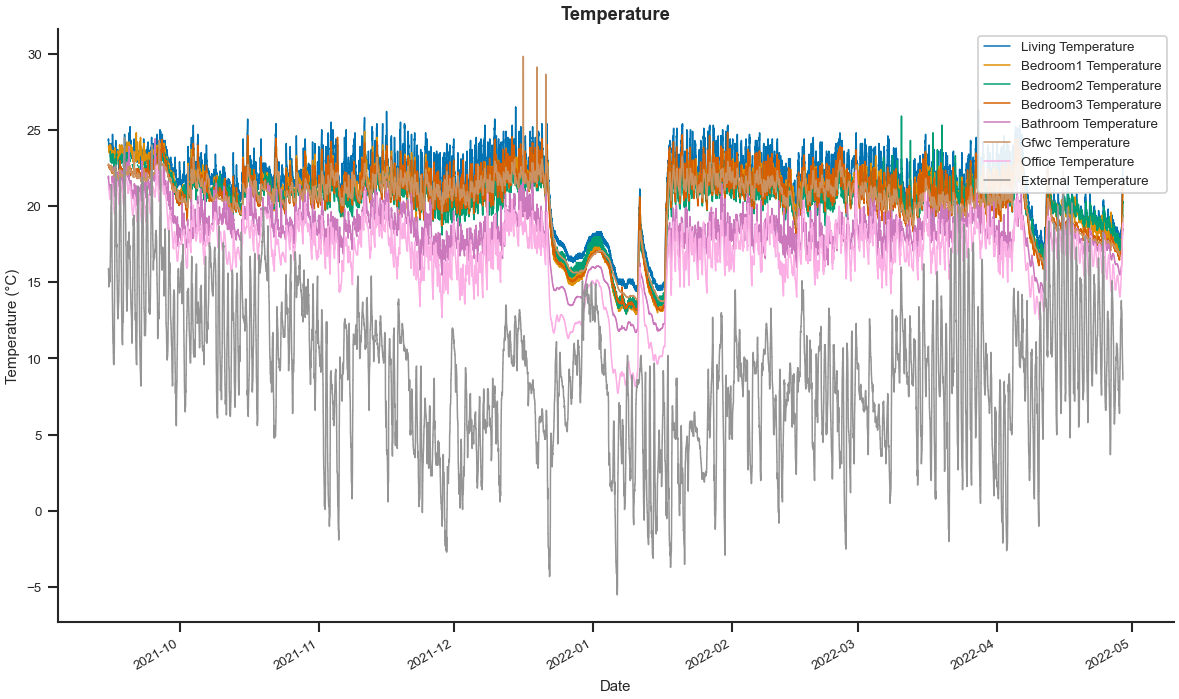

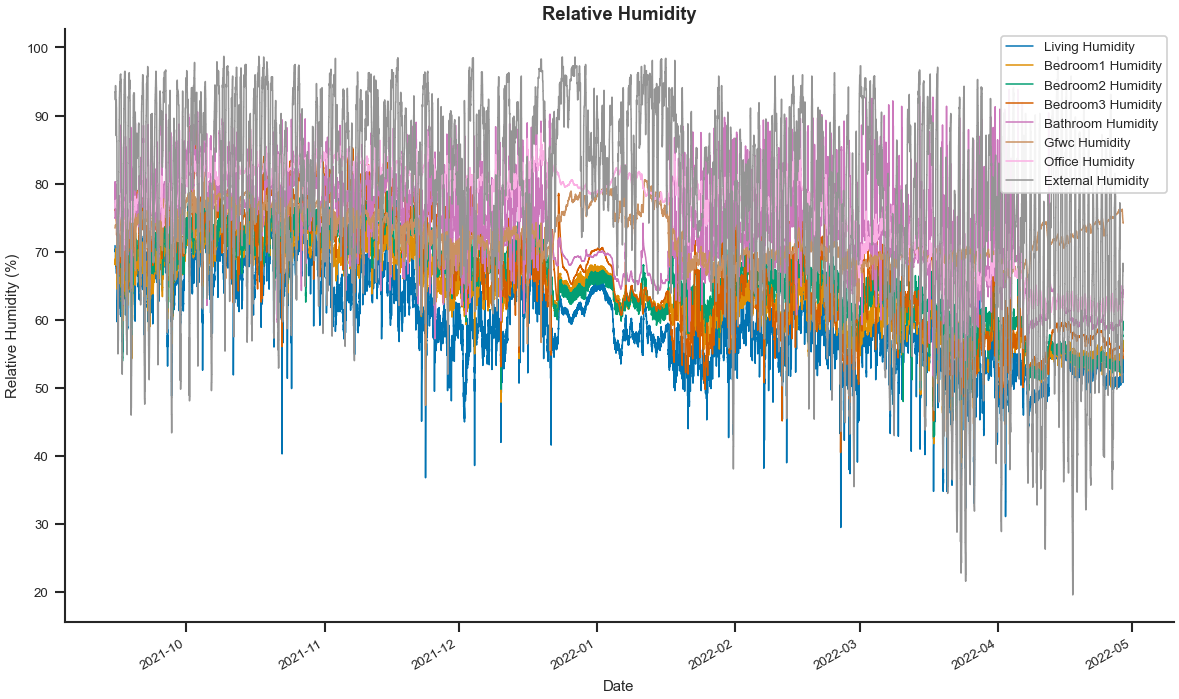

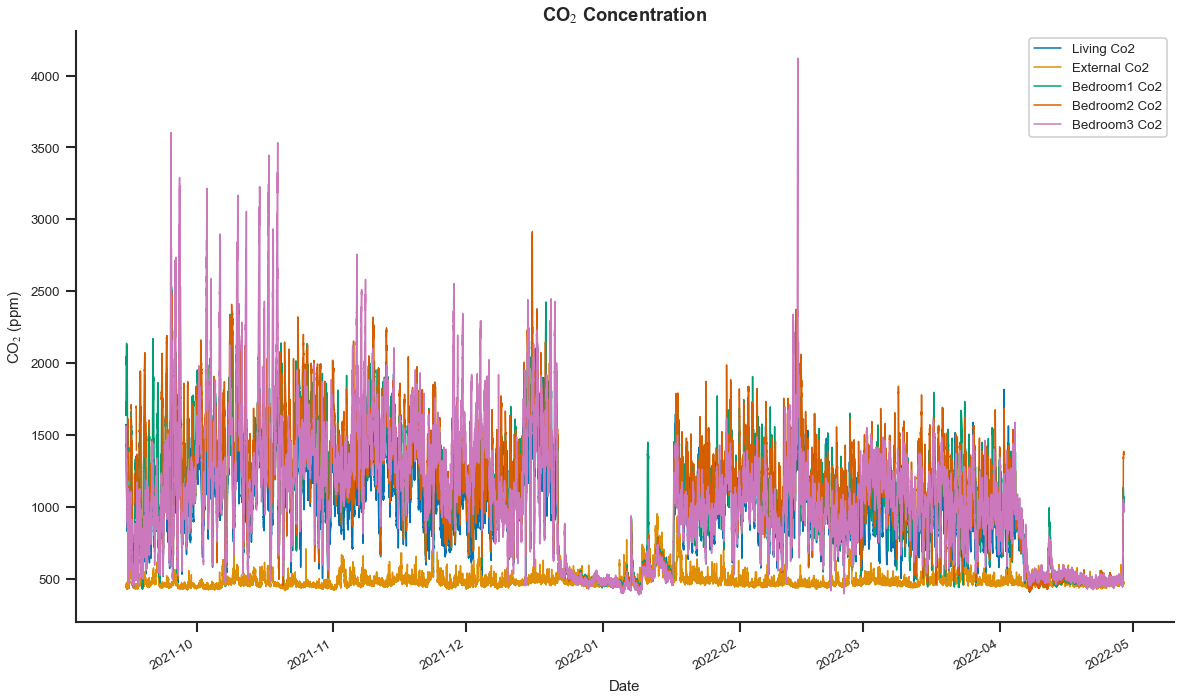

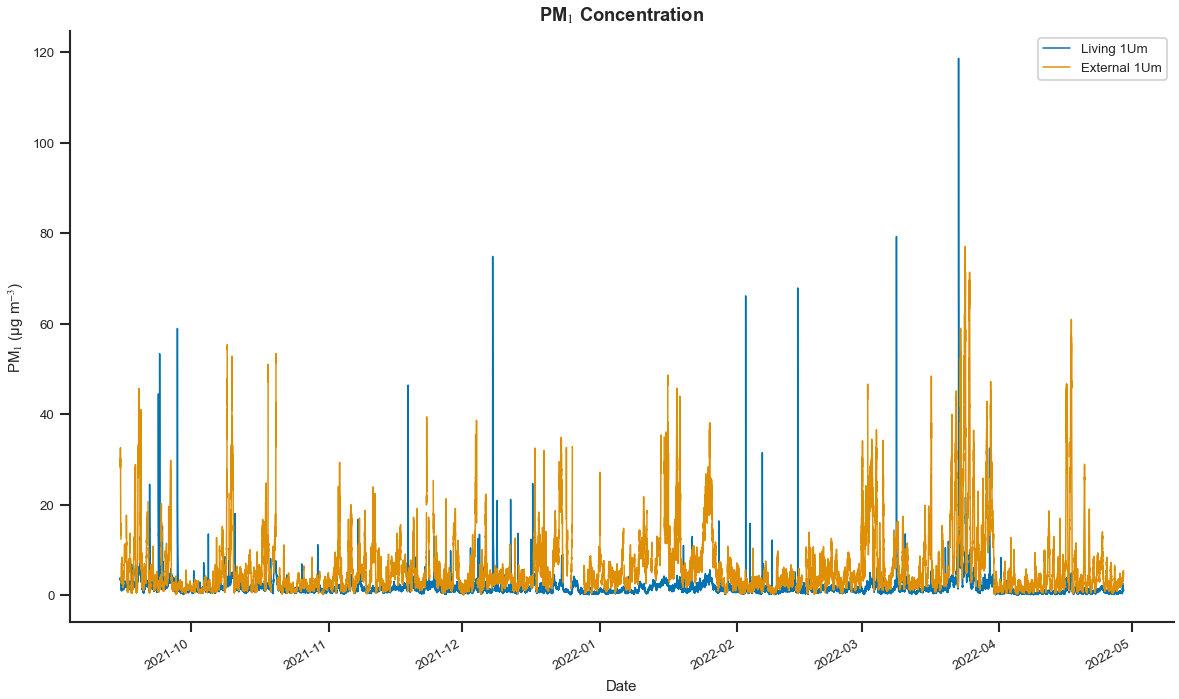

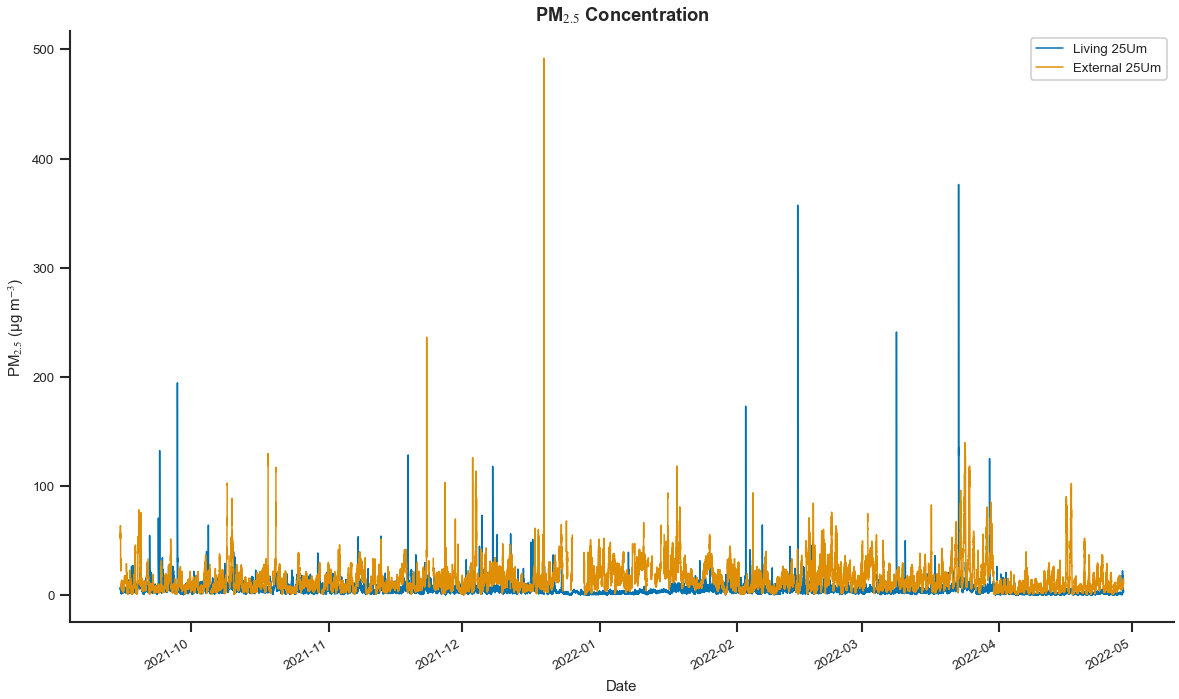

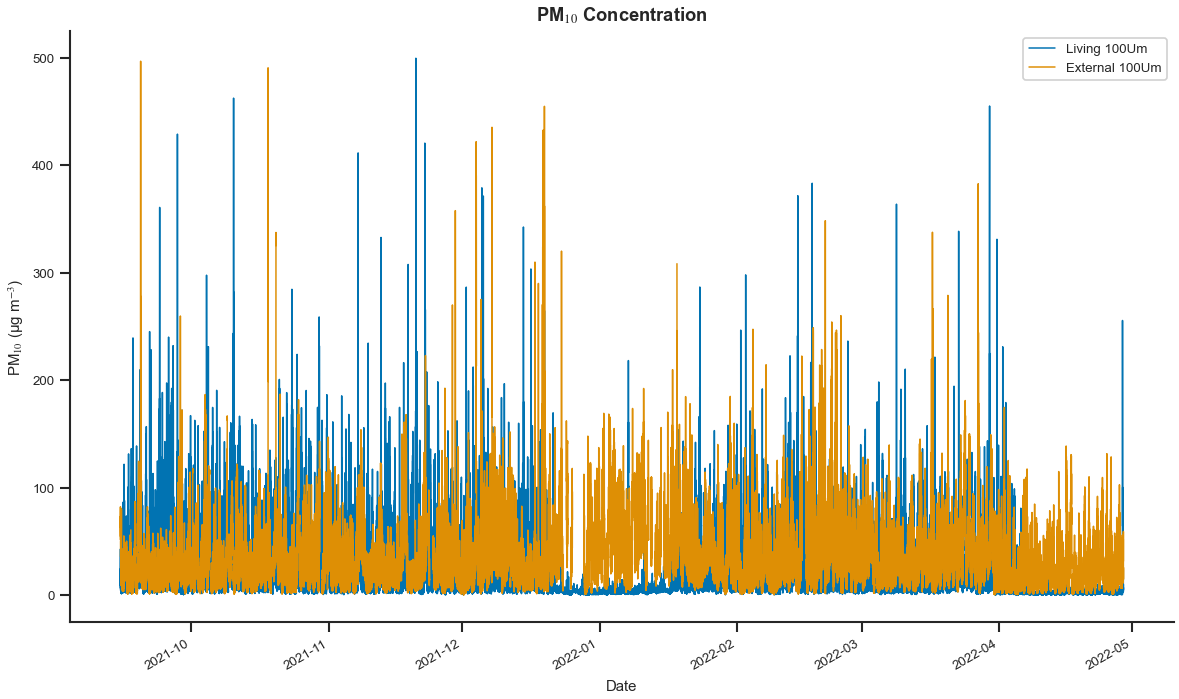

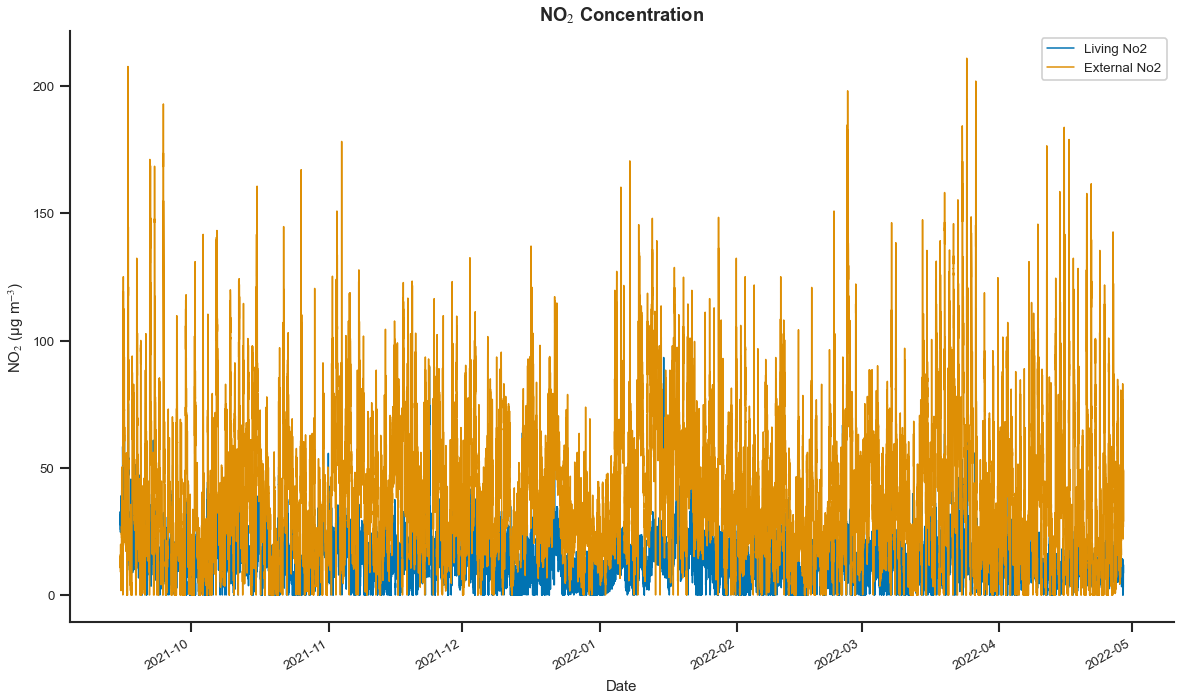

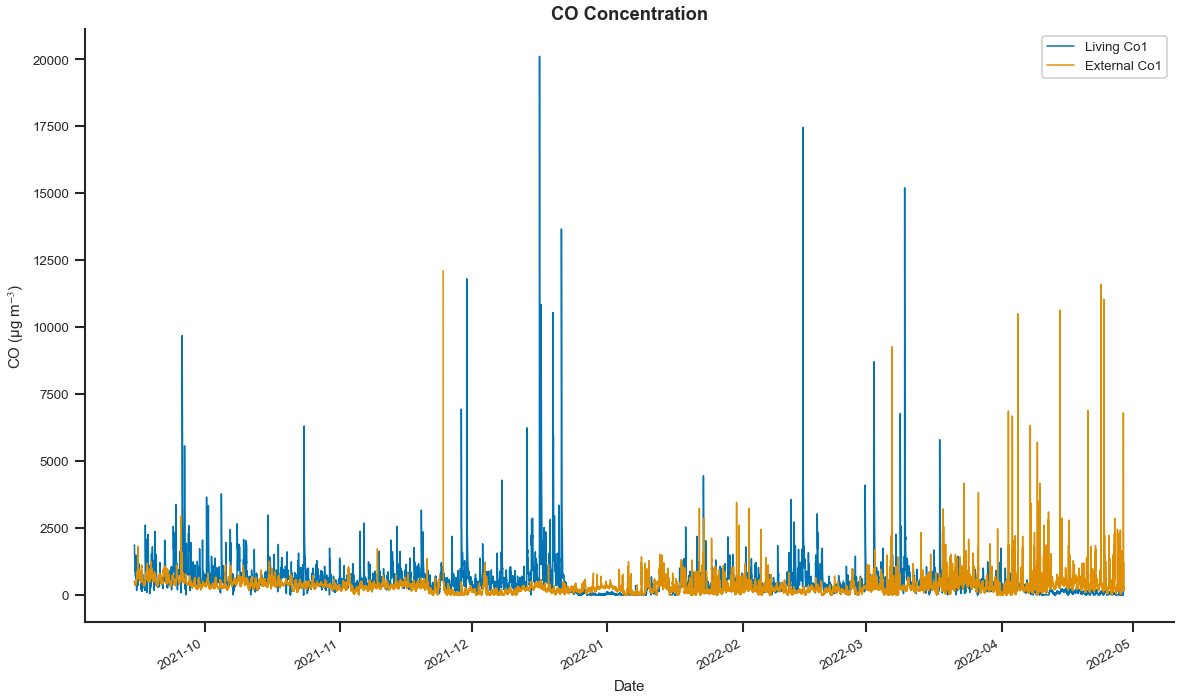

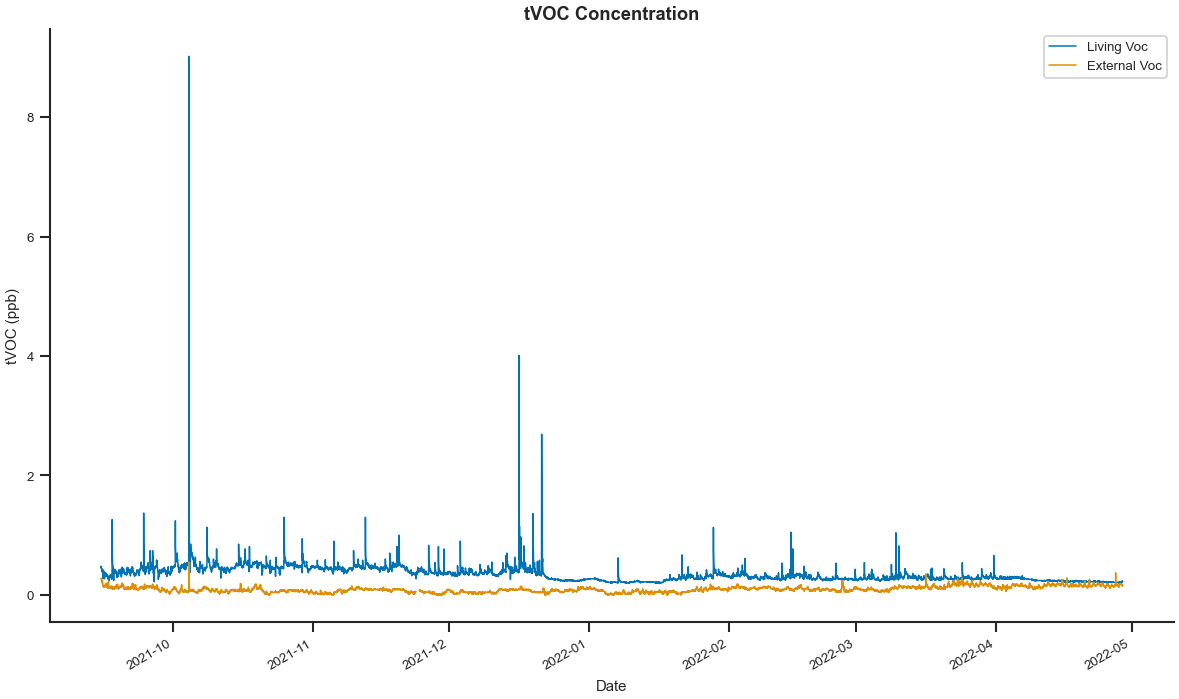

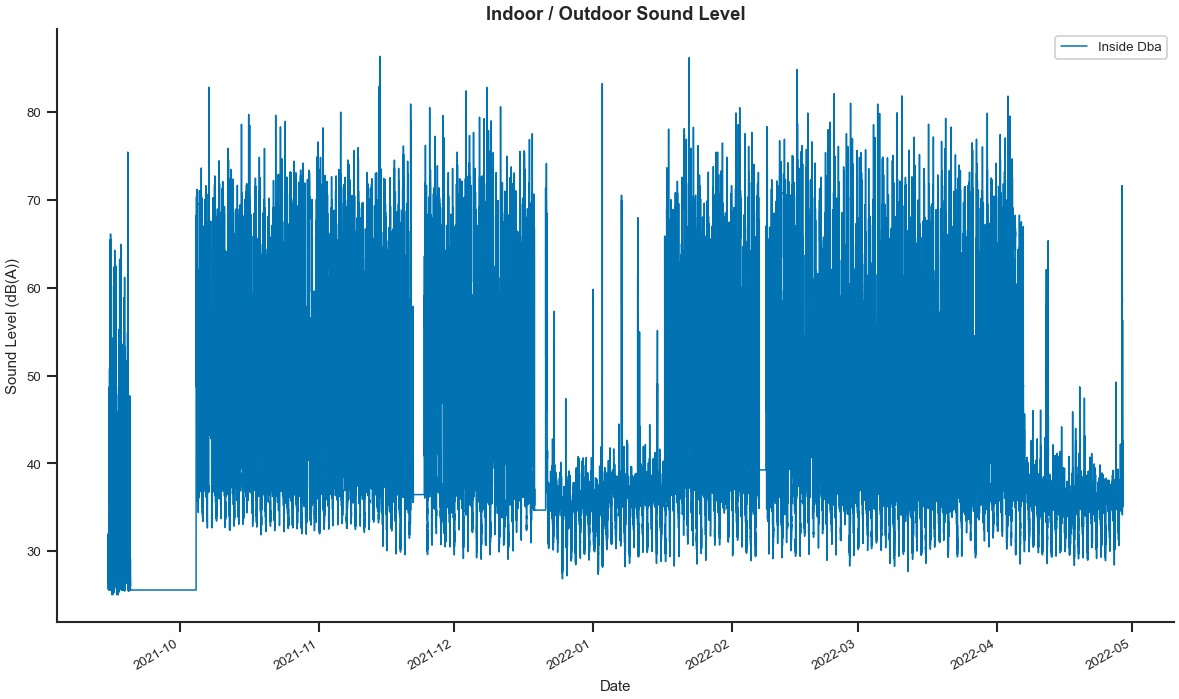

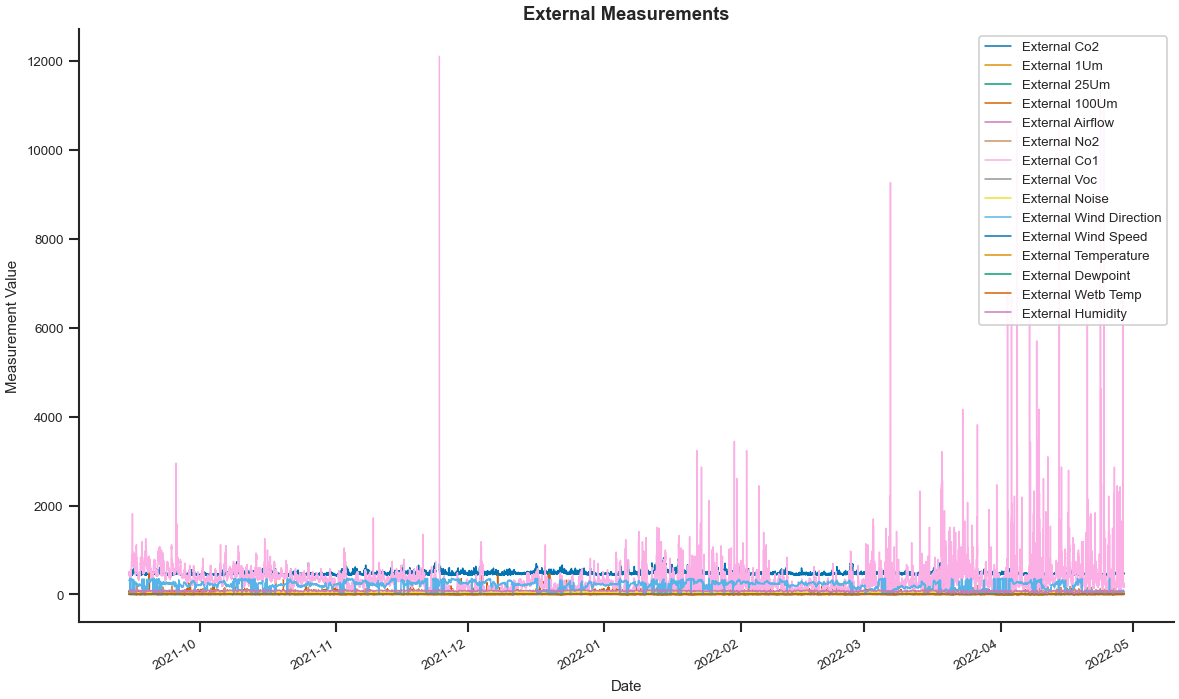

In [24]:
plot_grouped_variables(input_dataframe=p7, input_save=True, save_path="../data/p7_london_terraced/plots/", figsize=(10, 6), dpi=300)

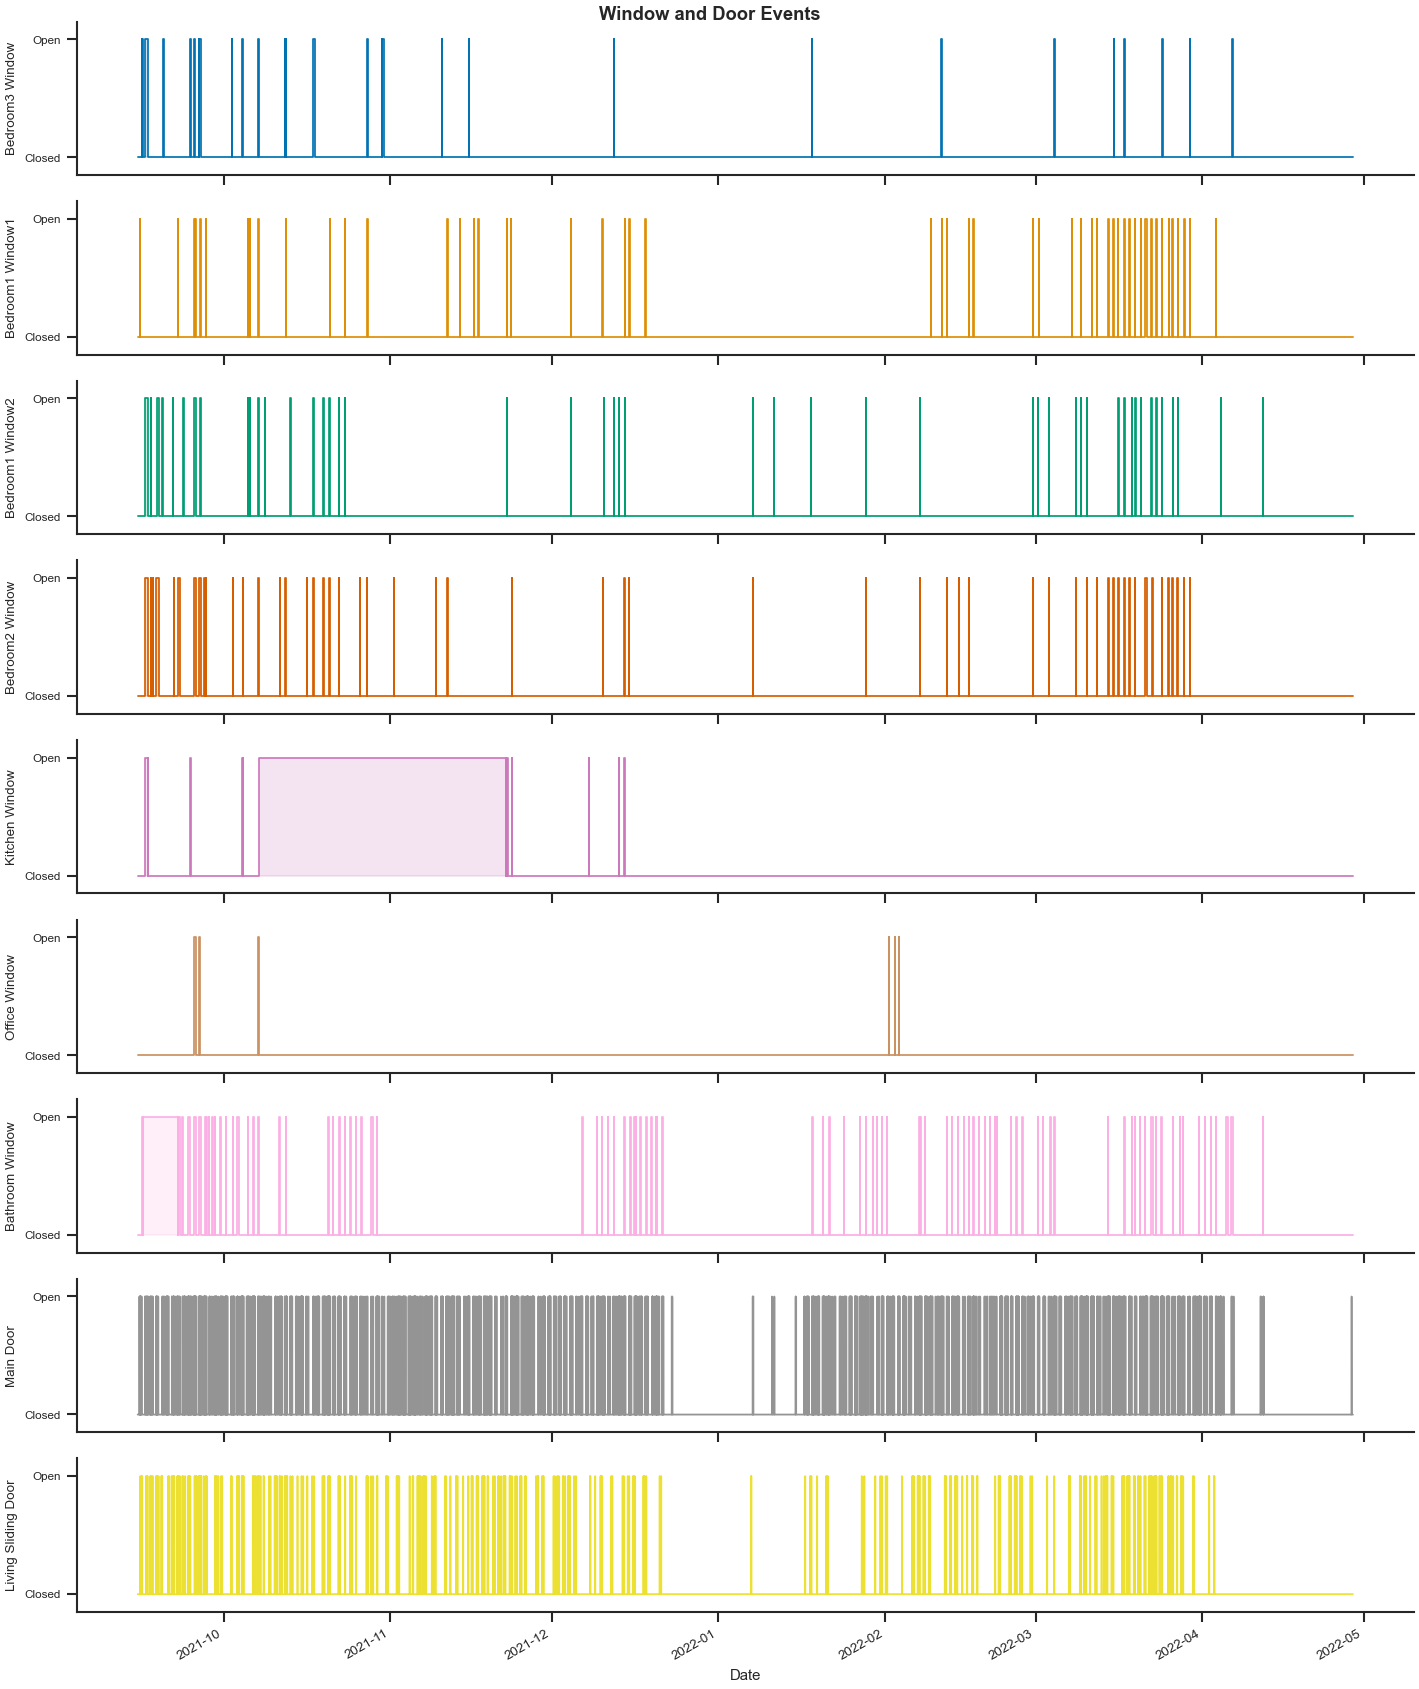

In [25]:
plot_event_timeseries(input_event_dict=p7_event_dict,
                      input_start_date=monitoring_start_date,
                      input_end_date=monitoring_end_date,
                      input_save=True,
                      save_path='../data/p7_london_terraced/plots/')

## Summary Statistics

In [26]:
p7_continuous_stats, p7_event_stats = summary_statistics(
    input_dataframe=p7,
    input_rooms_and_variables=p7_rooms_and_variables,
    input_event_dict=p7_event_dict,
    input_rooms_and_events=p7_rooms_and_events
)

# Print the number of days of data collected
num_days = (p7.index[-1] - p7.index[0]).days
print(f"Number of days of data collected: {num_days} days")


====    Summary Statistics    ====

--- Continuous Variables ---

  bathroom_temperature: n=65089, n_missing=0, mean=18.038, median=18.343
  bathroom_humidity: n=65089, n_missing=0, mean=71.889, median=72.331
  bathroom_light: n=65089, n_missing=0, mean=62.312, median=11.8
  external_co2: n=64858, n_missing=231, mean=483.58, median=472.0
  external_1um: n=59946, n_missing=5143, mean=5.813, median=3.38
  external_25um: n=59946, n_missing=5143, mean=13.977, median=10.44
  external_100um: n=59902, n_missing=5187, mean=32.422, median=24.72
  external_airflow: n=64858, n_missing=231, mean=3.346, median=3.4
  external_no2: n=64858, n_missing=231, mean=38.517, median=33.278
  external_co1: n=64858, n_missing=231, mean=293.089, median=256.124
  external_voc: n=64858, n_missing=231, mean=0.092, median=0.09
  external_noise: n=65089, n_missing=0, mean=56.453, median=59.42
  external_wind_direction: n=65089, n_missing=0, mean=206.116, median=230.0
  external_wind_speed: n=65089, n_missing=0, mea

## Save outputs

In [27]:
save_participant_outputs(
    n=7,
    df=p7,
    event_dict=p7_event_dict,
    rooms_and_variables=p7_rooms_and_variables,
    rooms_and_events=p7_rooms_and_events,
    rooms_list=p7_rooms_list,
    continuous_stats=p7_continuous_stats,
    event_stats=p7_event_stats,
data_dir='../data/p7_london_terraced')

p7 outputs saved to ../data/p7_london_terraced/data_processed/p7_outputs.pkl
